# UniversalStripeRemover — Tiled Batch Processing Test

Tests `process_tiled()` with **n=1** (no split), **n=2** (2×2), **n=3** (3×3).  
Each configuration tiles the image, processes all tiles as a batch, then reassembles with cosine overlap blending.

In [1]:
%load_ext autoreload
%autoreload 2

import time
import torch

import matplotlib.pyplot as plt
import numpy as np

from PIL import Image


print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(device=0))


PyTorch: 2.10.0+cu126
CUDA: True
GPU: NVIDIA GeForce RTX 2060


## 1. Load Sample Image

Image shape: torch.Size([487, 757])
Value range: [0.1333, 1.0000]


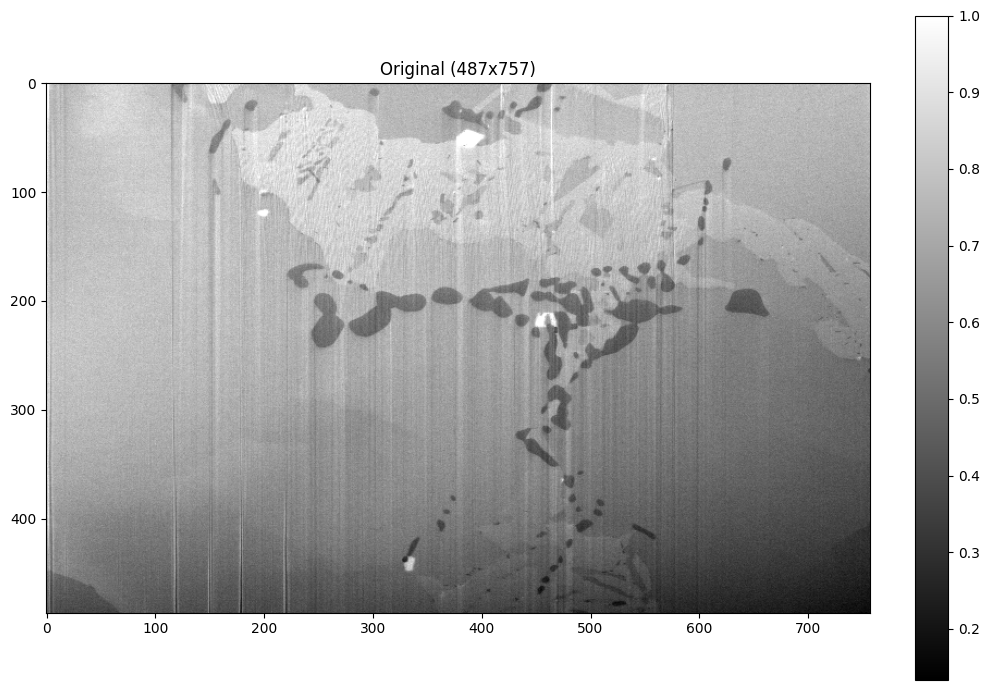

In [2]:
img = np.array(object=Image.open(fp="sample.png").convert(mode="L"), dtype=np.float32) / 255.0
f_tensor = torch.from_numpy(img)

print(f"Image shape: {f_tensor.shape}")
print(f"Value range: [{f_tensor.min().item():.4f}, {f_tensor.max().item():.4f}]")

plt.figure(figsize=(10, 7))
plt.imshow(X=f_tensor.numpy(), cmap="gray")
plt.title(label=f"Original ({f_tensor.shape[0]}x{f_tensor.shape[1]})")
plt.colorbar(fraction=0.046)
plt.tight_layout()
plt.show()


## 2. Run Tiled Processing (n=1, 2, 3)

In [3]:
from remover import UniversalStripeRemover


remover = UniversalStripeRemover(mu1=0.33, mu2=0.003)

results = {}
timings = {}

for n_tile in [1, 2, 3]:
    label = f"{n_tile}x{n_tile}"
    print("\n" + "=" * 60)
    print(f"Processing: n={n_tile} ({label})")
    print("=" * 60)

    t0 = time.time()
    result = remover.process_tiled(
        image=f_tensor,
        n=n_tile,
        iterations=500,
        tol=1e-5,
        overlap=64,
        proj=True,
        verbose=True,
    )
    elapsed = time.time() - t0

    results[n_tile] = result
    timings[n_tile] = elapsed
    print(f"Time: {elapsed:.1f}s | Shape: {result.shape} | Range: [{result.min().item():.4f}, {result.max().item():.4f}]")

print("\n--- Timing Summary ---")
for n_tile, t in timings.items():
    print(f"  n={n_tile}: {t:.1f}s")



Processing: n=1 (1x1)
Iteration: 500 / 500
Time: 2.7s | Shape: torch.Size([487, 757]) | Range: [0.1968, 0.9906]

Processing: n=2 (2x2)
Tiling 2x2: 4 tiles of 366x501, overlap=61
Iteration: 500 / 500
Time: 1.9s | Shape: torch.Size([487, 757]) | Range: [0.1626, 1.0000]

Processing: n=3 (3x3)
Tiling 3x3: 9 tiles of 243x333, overlap=40
Iteration: 500 / 500
Time: 1.9s | Shape: torch.Size([487, 757]) | Range: [0.1558, 1.0000]

--- Timing Summary ---
  n=1: 2.7s
  n=2: 1.9s
  n=3: 1.9s


## 3. Visual Comparison (n=1, 2, 3)

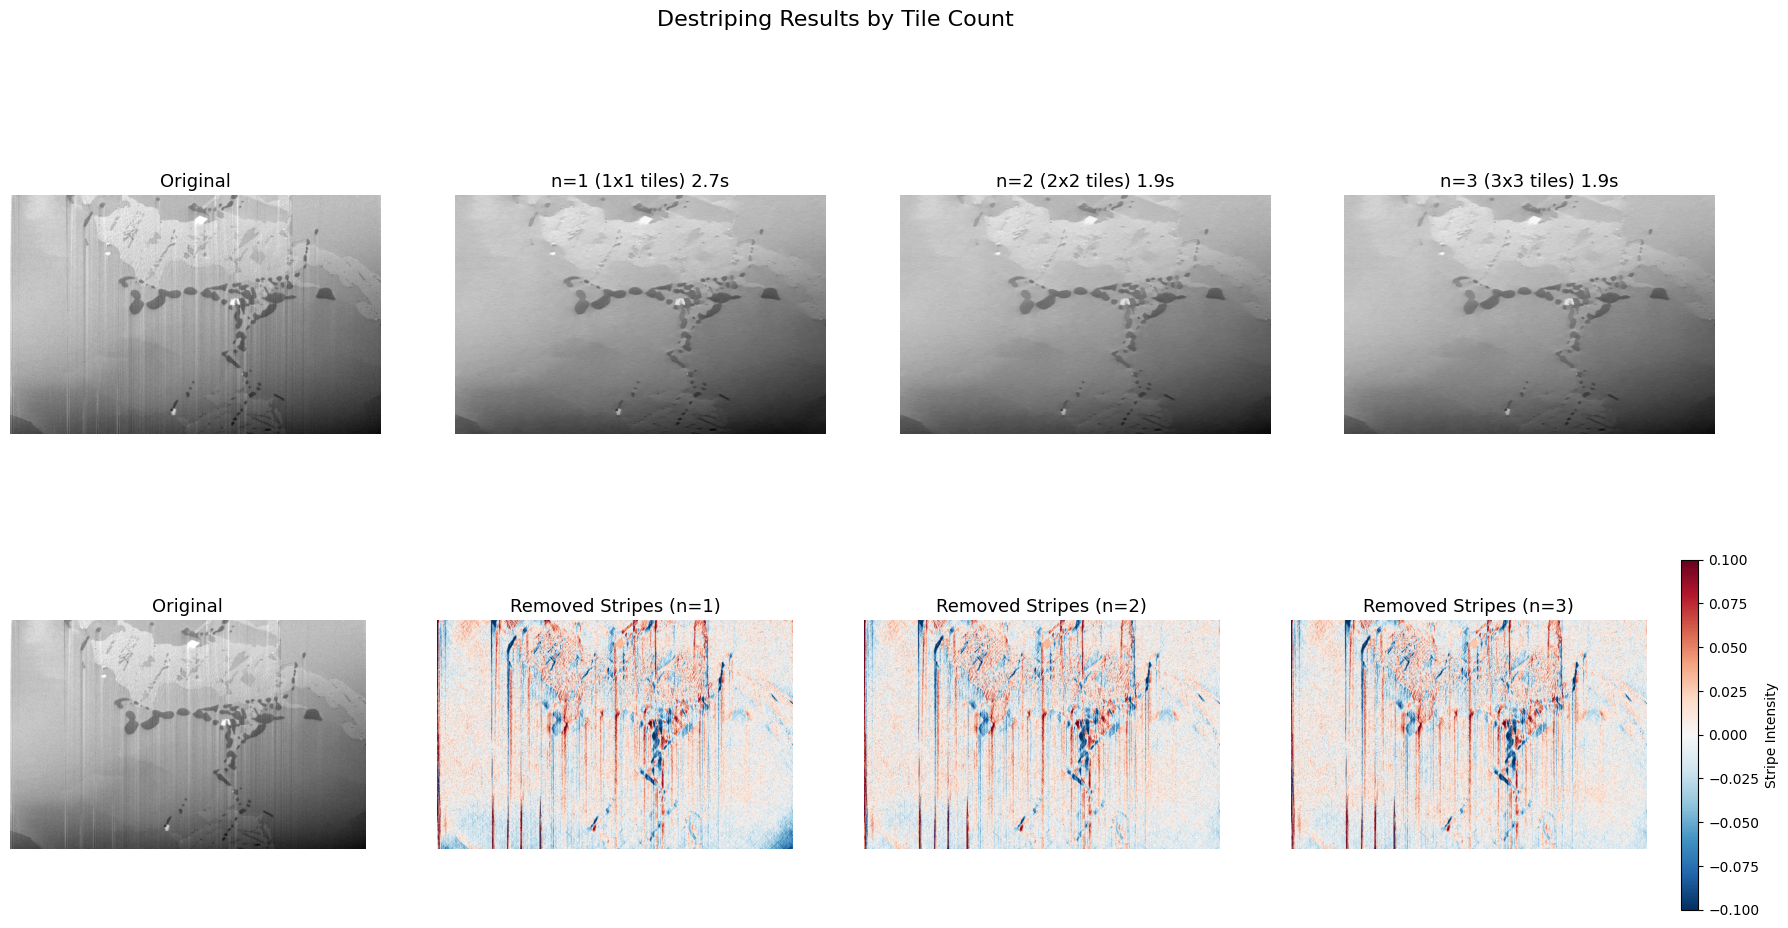

In [4]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(22, 10))

axes[0, 0].imshow(X=f_tensor.numpy(), cmap="gray")
axes[0, 0].set_title(label="Original", fontsize=13)

for idx, n_tile in enumerate([1, 2, 3]):
    ax = axes[0, idx + 1]
    ax.imshow(X=results[n_tile].numpy(), cmap="gray")
    ax.set_title(label=f"n={n_tile} ({n_tile}x{n_tile} tiles) {timings[n_tile]:.1f}s", fontsize=13)

vmin = -0.1
vmax = 0.1

axes[1, 0].imshow(X=f_tensor.numpy(), cmap="gray")
axes[1, 0].set_title(label="Original", fontsize=13)

for idx, n_tile in enumerate([1, 2, 3]):
    ax = axes[1, idx + 1]
    stripe = (f_tensor - results[n_tile]).numpy()
    im = ax.imshow(X=stripe, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax.set_title(label=f"Removed Stripes (n={n_tile})", fontsize=13)

for ax in axes.flat:
    ax.axis(False)

fig.colorbar(mappable=im, ax=axes[1, :].tolist(), fraction=0.02, pad=0.02, label="Stripe Intensity")
plt.suptitle(t="Destriping Results by Tile Count", fontsize=16, y=1.01)
plt.show()


## 4. Seamless Check — Zoom into Tile Boundaries

If the overlap blending works, there should be **no visible seams** at tile boundaries.

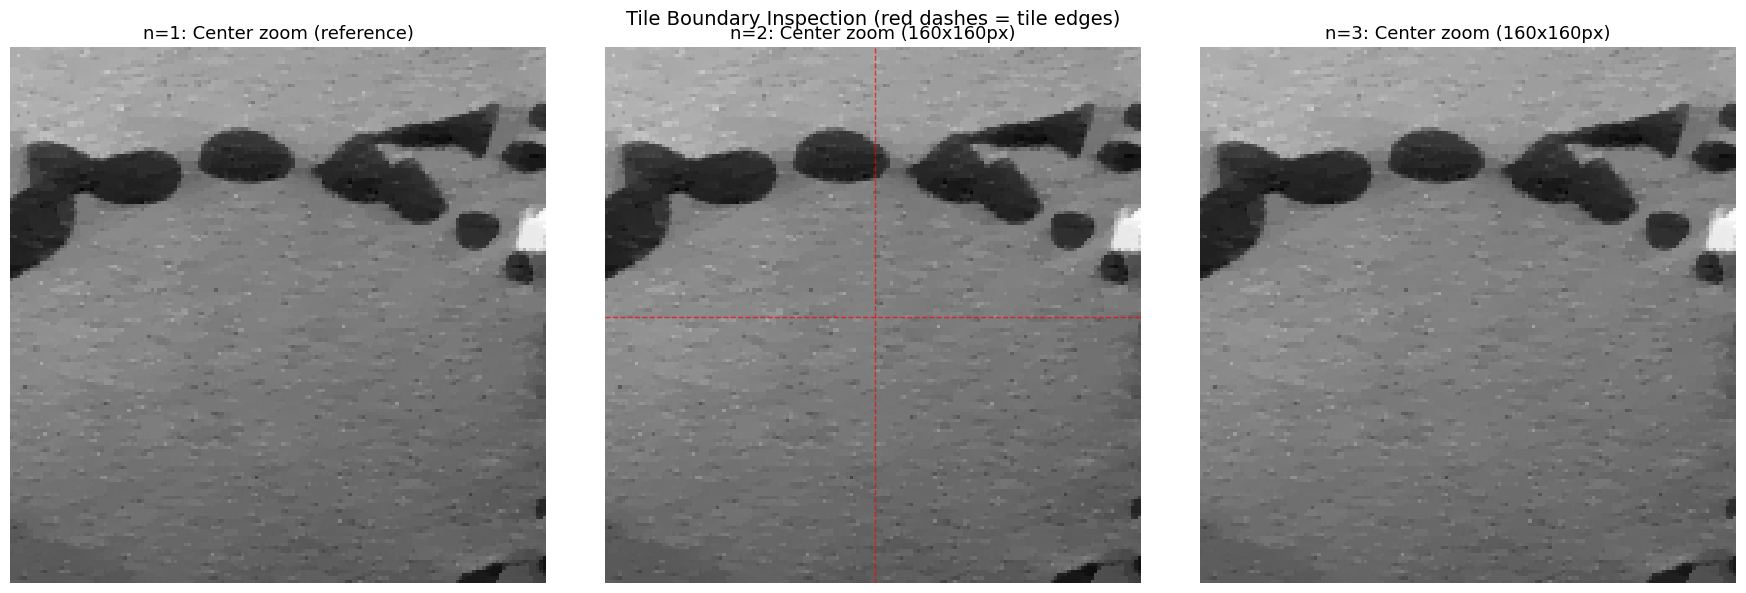

In [5]:
h, w = f_tensor.shape
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for idx, n_tile in enumerate([1, 2, 3]):
    ax = axes[idx]
    res = results[n_tile].numpy()

    cy, cx = h // 2, w // 2
    margin = 80
    region = res[cy - margin : cy + margin, cx - margin : cx + margin]
    ax.imshow(X=region, cmap="gray")

    if n_tile >= 2:
        ax.set_title(label=f"n={n_tile}: Center zoom ({2 * margin}x{2 * margin}px)", fontsize=13)
        tile_h, tile_w = h // n_tile, w // n_tile
        for ti in range(1, n_tile):
            by = ti * tile_h - (cy - margin)
            bx = ti * tile_w - (cx - margin)
            if 0 <= by < 2 * margin:
                ax.axhline(y=by, color="red", linewidth=1, linestyle="--", alpha=0.7)
            if 0 <= bx < 2 * margin:
                ax.axvline(x=bx, color="red", linewidth=1, linestyle="--", alpha=0.7)
    else:
        ax.set_title(label="n=1: Center zoom (reference)", fontsize=13)
    ax.axis(False)

plt.suptitle(t="Tile Boundary Inspection (red dashes = tile edges)", fontsize=14)
plt.tight_layout()
plt.show()


## 5. Line Profile across Tile Boundaries

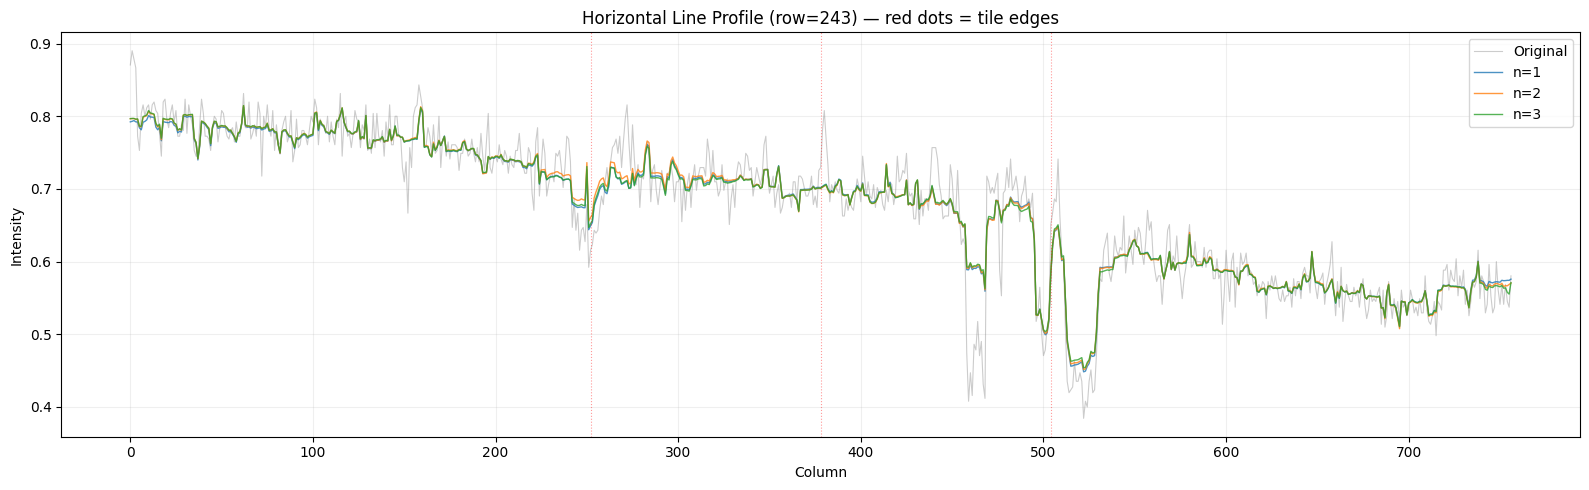

In [6]:
row = h // 2
plt.figure(figsize=(16, 5))
plt.plot(f_tensor[row, :].numpy(), alpha=0.4, label="Original", linewidth=0.8, color="gray")

for n_tile in [1, 2, 3]:
    plt.plot(results[n_tile][row, :].numpy(), alpha=0.8, label=f"n={n_tile}", linewidth=1.0)

for n_tile in [2, 3]:
    tw = w // n_tile
    for tj in range(1, n_tile):
        plt.axvline(x=tj * tw, color="red", linewidth=0.8, linestyle=":", alpha=0.4)

plt.title(label=f"Horizontal Line Profile (row={row}) — red dots = tile edges")
plt.xlabel(xlabel="Column")
plt.ylabel(ylabel="Intensity")
plt.legend()
plt.grid(visible=True, alpha=0.2)
plt.tight_layout()
plt.show()


## 6. Quantitative Comparison (n=1 as reference)

In [7]:
ref = results[1]
header = f"{'n':>5} | {'Rel. Diff vs n=1':>18} | {'Max Diff':>10} | {'PSNR(input->result)':>20}"
print(header)
print("-" * len(header))

for n_tile in [1, 2, 3]:
    res = results[n_tile]
    rel_diff = torch.norm(input=res - ref) / torch.norm(input=ref)
    max_diff = (res - ref).abs().max()

    mse = torch.mean(input=(f_tensor - res) ** 2)
    if mse > 0:
        psnr = 10 * torch.log10(input=1.0 / mse)
    else:
        psnr = torch.tensor(data=float("inf"))

    print(f"{n_tile:>5} | {rel_diff.item():>18.6f} | {max_diff.item():>10.6f} | {psnr.item():>18.2f} dB")


    n |   Rel. Diff vs n=1 |   Max Diff |  PSNR(input->result)
--------------------------------------------------------------
    1 |           0.000000 |   0.000000 |              30.51 dB
    2 |           0.007137 |   0.099677 |              30.68 dB
    3 |           0.007779 |   0.106928 |              30.63 dB


## 7. Adjoint Consistency Test

In [8]:
from remover import UniversalStripeRemover


r = UniversalStripeRemover(device="cpu")
shape = (1, 32, 32)
torch.manual_seed(seed=42)

print("=== Adjoint Consistency: <Df, g> == <f, D^T g> ===")
print(f"{'Operator':<12} {'<Df, g>':>16} {'<f, D^T g>':>16} {'Rel Error':>12} {'':>5}")
print("-" * 65)

all_pass = True
labels = ["vert(0)", "26.6L", "45L", "26.6R", "45R"]

for mode in range(5):
    f_vec = torch.randn(size=shape)
    g_vec = torch.randn(size=shape)
    d_f = r._dir_diff(x=f_vec, mode=mode)
    dt_g = torch.zeros_like(input=g_vec)
    r._adj_dir(target=dt_g, q=g_vec, mode=mode, a=1.0)
    dt_g = -dt_g
    lhs = torch.sum(input=d_f * g_vec).item()
    rhs = torch.sum(input=f_vec * dt_g).item()
    err = abs(lhs - rhs) / (abs(lhs) + 1e-12)
    ok = err < 1e-5
    all_pass = all_pass and ok
    status = "PASS" if ok else "FAIL"
    print(f"{labels[mode]:<12} {lhs:>16.8f} {rhs:>16.8f} {err:>12.2e} {status:>5}")

for dim, name in [(1, "grad_h"), (2, "grad_v")]:
    f_vec = torch.randn(size=shape)
    g_vec = torch.randn(size=shape)
    d_f = r._fwd(x=f_vec, dim=dim)
    dt_g = torch.zeros_like(input=g_vec)

    if dim == 1:
        r._adj_grad(target=dt_g, ph=g_vec, pv=torch.zeros_like(input=g_vec), a=1.0)
    else:
        r._adj_grad(target=dt_g, ph=torch.zeros_like(input=g_vec), pv=g_vec, a=1.0)

    dt_g = -dt_g
    lhs = torch.sum(input=d_f * g_vec).item()
    rhs = torch.sum(input=f_vec * dt_g).item()
    err = abs(lhs - rhs) / (abs(lhs) + 1e-12)
    ok = err < 1e-5
    all_pass = all_pass and ok
    status = "PASS" if ok else "FAIL"
    print(f"{name:<12} {lhs:>16.8f} {rhs:>16.8f} {err:>12.2e} {status:>5}")

print()
if all_pass:
    print("All tests PASSED")
else:
    print("Some tests FAILED")


=== Adjoint Consistency: <Df, g> == <f, D^T g> ===
Operator              <Df, g>       <f, D^T g>    Rel Error      
-----------------------------------------------------------------
vert(0)           29.85549927      29.85549927     0.00e+00  PASS
26.6L           -100.50485229    -100.50484467     7.59e-08  PASS
45L              -67.93233490     -67.93232727     1.12e-07  PASS
26.6R            -17.86000252     -17.86001205     5.34e-07  PASS
45R               37.39154053      37.39154053     0.00e+00  PASS
grad_h           -27.56414986     -27.56415558     2.08e-07  PASS
grad_v           -40.49198151     -40.49198151     0.00e+00  PASS

All tests PASSED
